In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
import sys, os
sys.path.append("..")


In [16]:
df = pd.read_csv('../data/adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [17]:
df = df.replace("?", pd.NA)

In [18]:
missing = df.isna().sum()
missing = missing[missing>0]

(array([0, 1, 2]),
 [Text(0, 0, 'workclass'),
  Text(1, 0, 'occupation'),
  Text(2, 0, 'native-country')])

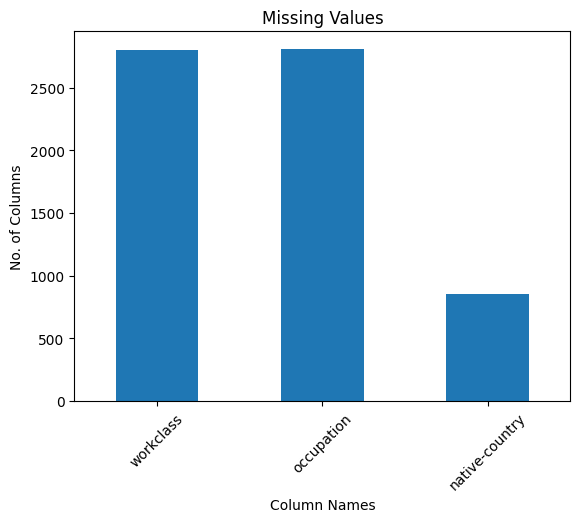

In [19]:
missing.plot(kind='bar')
plt.title("Missing Values")
plt.xlabel('Column Names')
plt.ylabel('No. of Columns')
plt.xticks(rotation=45)

Text(0, 0.5, 'No. of values')

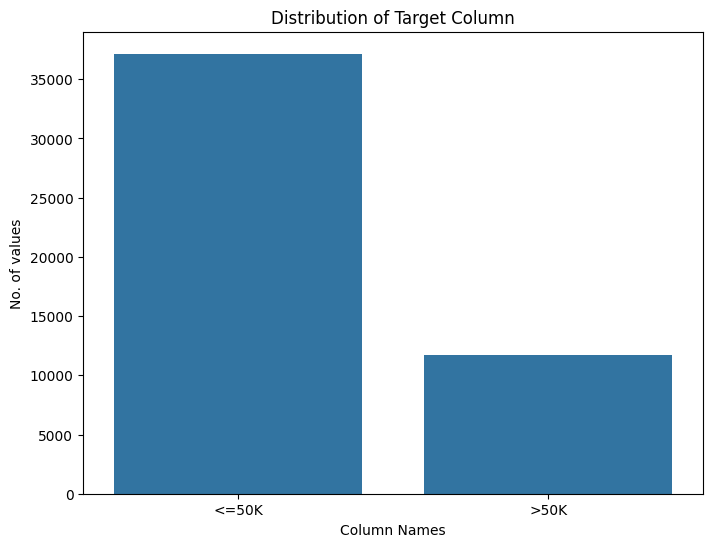

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(
    data = df,
    x = 'income'
)
plt.title("Distribution of Target Column")
plt.xlabel('Column Names')
plt.ylabel('No. of values')


In [21]:
from src.utils import get_feature_type

num_cols, categorical_cols = get_feature_type(df)

df[num_cols].describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


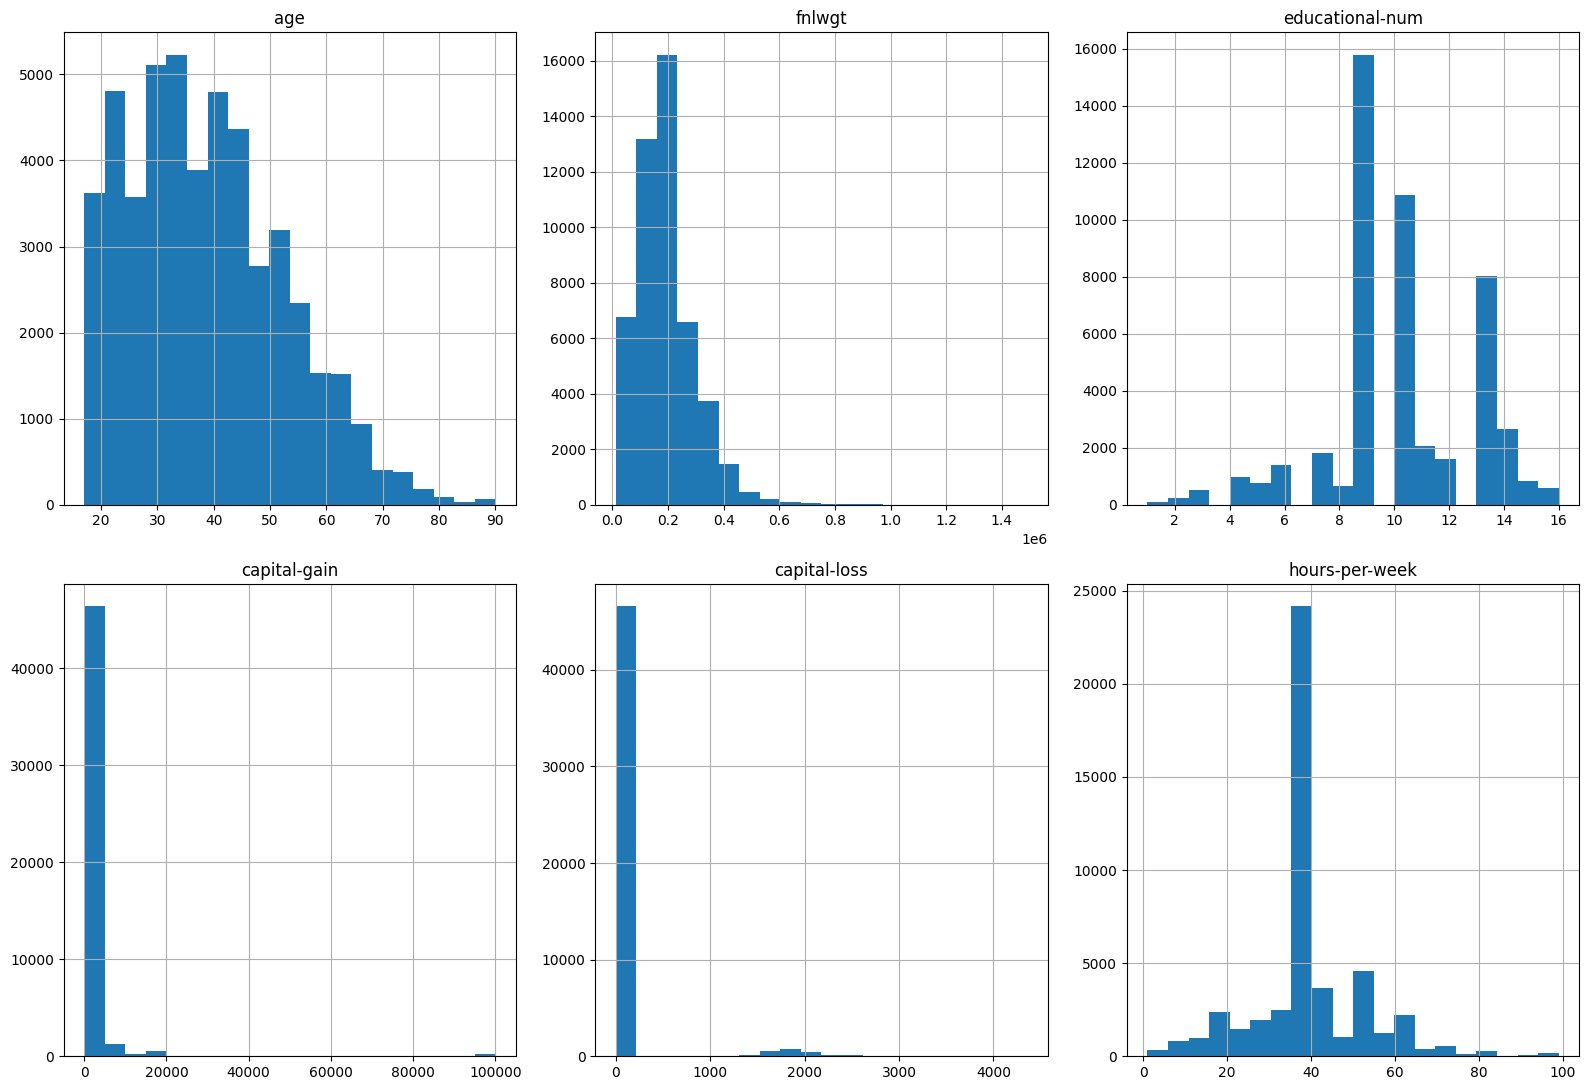

In [22]:
import matplotlib.pyplot as plt

# 1. Plot all numeric columns at once as a grid
df[num_cols].hist(bins=20, figsize=(16, 11), layout=(2, 3)) 

# 2. Automatically fix any overlapping text/labels
plt.tight_layout()

# 3. Render the single sheet
plt.show()

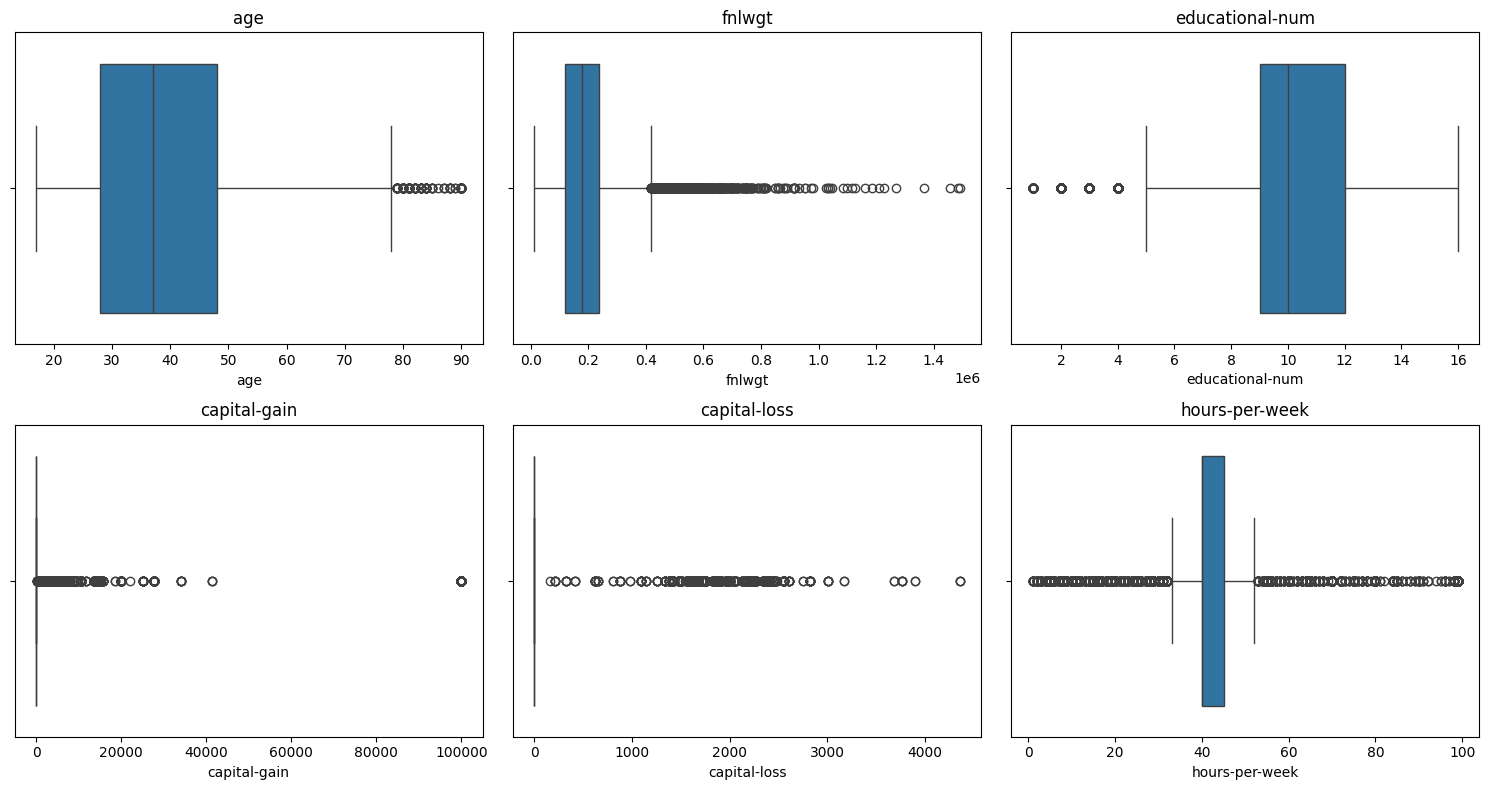

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()

In [24]:
df_corr = df.copy()

df_corr['income'] = (
    df_corr['income']
    .map({
        "<=50K": 0,
        ">50K": 1
    })
)

                      age    fnlwgt  educational-num  capital-gain  \
income           0.230369 -0.006339         0.332613      0.223013   
educational-num  0.030940 -0.038761         1.000000      0.125146   
age              1.000000 -0.076628         0.030940      0.077229   
hours-per-week   0.071558 -0.013519         0.143689      0.082157   
capital-gain     0.077229 -0.003706         0.125146      1.000000   
capital-loss     0.056944 -0.004366         0.080972     -0.031441   
fnlwgt          -0.076628  1.000000        -0.038761     -0.003706   

                 capital-loss  hours-per-week    income  
income               0.147554        0.227687  1.000000  
educational-num      0.080972        0.143689  0.332613  
age                  0.056944        0.071558  0.230369  
hours-per-week       0.054467        1.000000  0.227687  
capital-gain        -0.031441        0.082157  0.223013  
capital-loss         1.000000        0.054467  0.147554  
fnlwgt              -0.004366    

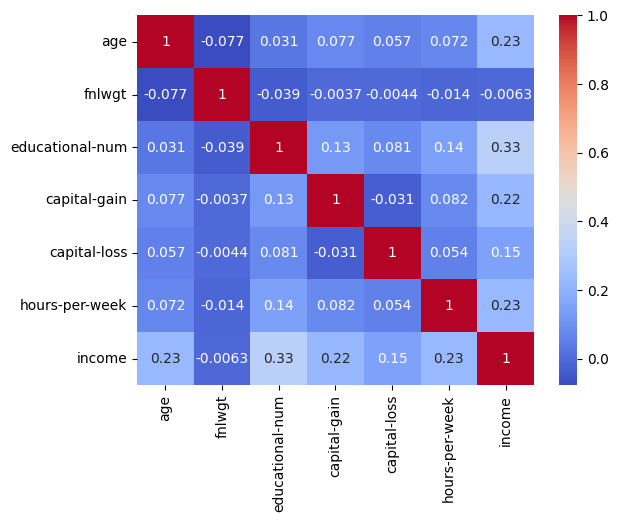

In [25]:
corr = df_corr.corr(numeric_only=True)

sns.heatmap(
    corr, 
    annot=True,
    cmap = 'coolwarm'
)

print(corr.sort_values(by = 'income',ascending=False))